In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import random
import shutil

In [11]:
# from google.colab import drive
# drive.mount('/content/drive')

In [12]:
# import zipfile
# import os


# # Path to your zip file in Drive
# zip_path = '/content/drive/MyDrive/MI-Intern/dataset.zip'

# # Extract the zip file
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall('/content/drive/MyDrive/MI-Intern')

# # Check extracted contents
# os.listdir('/content/drive/MyDrive/MI-Intern')

In [13]:
import os
from collections import Counter

# Paths
base_paths = {
    "train": "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test",
    "valid": "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/valid",
    "test": "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/train"
}

def count_labels(folder_path):
    label_path = os.path.join(folder_path, "labels")
    counter = Counter()

    if not os.path.exists(label_path):
        print(f"No labels folder found in {folder_path}")
        return counter

    for file in os.listdir(label_path):
        if file.endswith(".txt"):
            with open(os.path.join(label_path, file), "r") as f:
                for line in f:
                    class_id = line.strip().split()[0]  # YOLO format: class x y w h
                    counter[class_id] += 1

    return counter


all_labels = Counter()

for name, path in base_paths.items():
    counts = count_labels(path)
    print(f"\n{name.upper()} LABEL COUNTS:")
    print(counts)

    all_labels.update(counts)

print("\nTOTAL UNIQUE LABELS ACROSS TRAIN + VALID + TEST:")
print(len(all_labels.keys()))
print("Unique Label IDs:", sorted(all_labels.keys()))

# names: ['q1', 'q10', 'q100', 'q103', 'q106', 'q109', 'q112', 'q115', 'q118', 'q121', 'q13', 'q130', 'q133', 'q136', 'q142', 'q145', 'q148', 'q151', 'q157', 'q16', 'q163', 'q169', 'q175', 'q178', 'q184', 'q187', 'q19', 'q190', 'q193', 'q196', 'q199', 'q202', 'q211', 'q214', 'q22', 'q220', 'q229', 'q232', 'q247', 'q25', 'q250', 'q256', 'q262', 'q265', 'q268', 'q271', 'q274', 'q280', 'q286', 'q289', 'q291', 'q293', 'q299', 'q31', 'q34', 'q37', 'q4', 'q40', 'q46', 'q49', 'q52', 'q55', 'q58', 'q61', 'q64', 'q67', 'q7', 'q70', 'q73', 'q76', 'q79', 'q82', 'q88', 'q91', 'q94', 'q97']


TRAIN LABEL COUNTS:
Counter({'33': 19, '47': 18, '51': 16, '53': 12, '28': 10, '49': 8, '10': 8, '73': 4, '9': 4, '48': 4, '63': 4, '6': 3, '4': 3, '5': 3, '44': 3, '14': 3, '30': 3, '31': 3, '25': 3, '52': 2, '43': 2, '36': 2, '66': 2, '19': 1, '7': 1, '24': 1, '68': 1, '20': 1, '42': 1})

VALID LABEL COUNTS:
Counter({'10': 44, '47': 32, '53': 22, '15': 12, '22': 9, '18': 6, '59': 5, '41': 5, '58': 5, '1': 4, '36': 4, '7': 4, '48': 4, '42': 4, '56': 4, '4': 3, '6': 3, '5': 3, '40': 3, '35': 3, '19': 3, '23': 2, '43': 2, '63': 2, '8': 2, '17': 2, '65': 2, '38': 1, '32': 1, '25': 1, '2': 1, '60': 1})

TEST LABEL COUNTS:
Counter({'47': 393, '10': 384, '15': 357, '64': 225, '73': 221, '42': 162, '49': 114, '33': 99, '9': 99, '31': 99, '5': 93, '28': 87, '40': 81, '41': 69, '53': 63, '48': 60, '35': 60, '56': 60, '14': 57, '66': 54, '6': 48, '22': 48, '34': 48, '30': 45, '19': 45, '52': 44, '74': 42, '71': 42, '51': 42, '60': 39, '17': 39, '65': 33, '67': 30, '7': 30, '62': 30, '63': 24, 

Loaded Classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '8', '9']


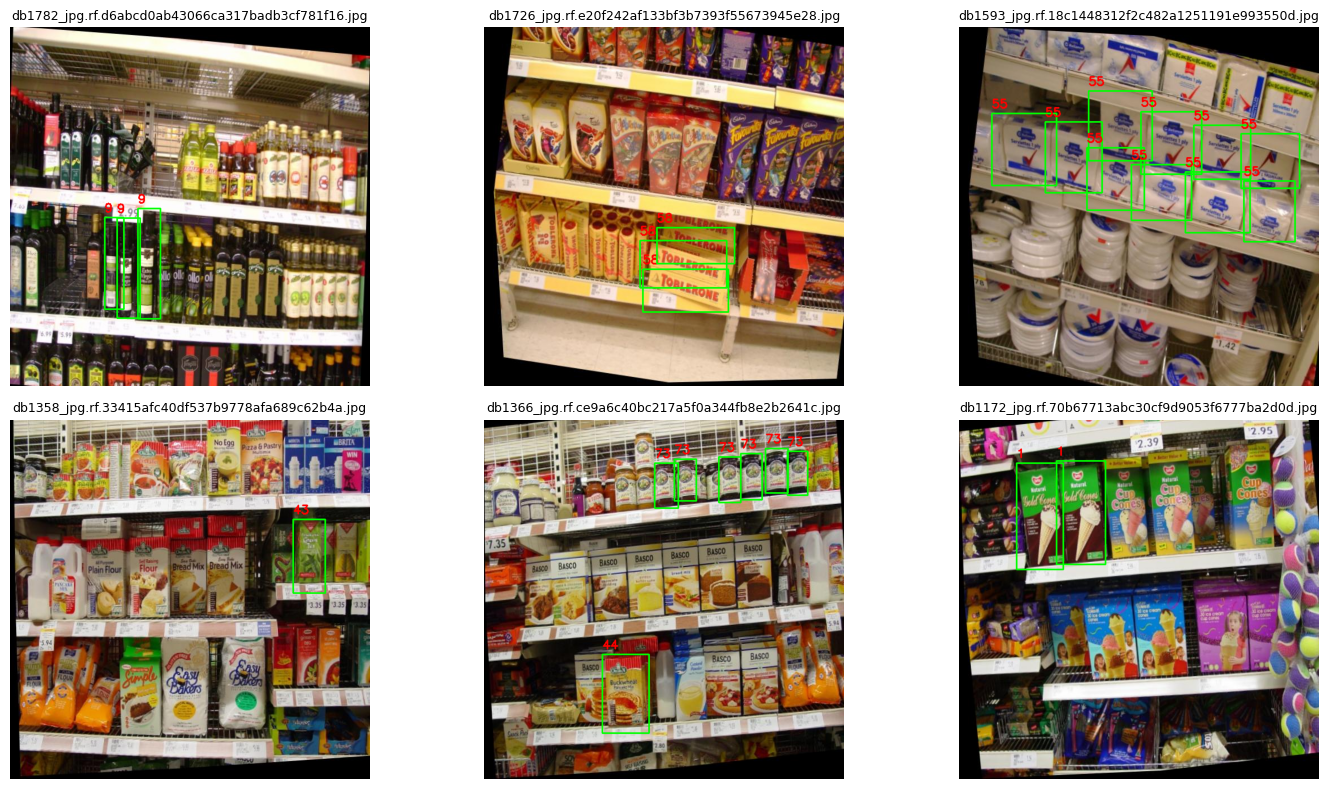

In [14]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import yaml

# ====== CONFIG ======
BASE_PATH = "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern"
SPLIT = "train"   # train / valid / test
NUM_IMAGES = 6
IMAGES_PER_ROW = 3

IMG_DIR = os.path.join(BASE_PATH, SPLIT, "images")
LBL_DIR = os.path.join(BASE_PATH, SPLIT, "labels")

IMG_EXTS = (".jpg", ".png", ".jpeg")

# ====== LOAD CLASS NAMES FROM data.yaml ======
yaml_path = os.path.join(BASE_PATH, "data.yaml")

with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml['names']   # automatically matches dataset
print("Loaded Classes:", class_names)

# ====== RANDOM IMAGE SELECTION ======
images = [f for f in os.listdir(IMG_DIR) if f.lower().endswith(IMG_EXTS)]
selected_images = random.sample(images, min(NUM_IMAGES, len(images)))

rows = (len(selected_images) + IMAGES_PER_ROW - 1) // IMAGES_PER_ROW
plt.figure(figsize=(15, 8))

# ====== VISUALIZATION ======
for idx, img_name in enumerate(selected_images):
    img_path = os.path.join(IMG_DIR, img_name)
    lbl_path = os.path.join(LBL_DIR, os.path.splitext(img_name)[0] + ".txt")

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f:
                cls_id, x, y, bw, bh = map(float, line.split())
                cls_id = int(cls_id)

                x1 = int((x - bw / 2) * w)
                y1 = int((y - bh / 2) * h)
                x2 = int((x + bw / 2) * w)
                y2 = int((y + bh / 2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    img,
                    str(class_names[cls_id]),
                    (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (255, 0, 0),
                    2
                )

    plt.subplot(rows, IMAGES_PER_ROW, idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name, fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
!pip install ultralytics
%matplotlib inline

In [16]:
from ultralytics import YOLO
from PIL import Image

# **yolo11n**

In [17]:
pretrained_model = YOLO("yolo11n.pt")

In [18]:
results = pretrained_model.train(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=20,
    project="/kaggle/working/sku_detection",
    name="yolo11n"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

In [20]:
from ultralytics import YOLO

# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11n2/weights/best.pt")

metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.25,      # lower threshold
    iou=0.5,
    plots=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,610,556 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 22.3±2.2 MB/s, size: 97.5 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 181.4it/s 0.2s.7s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.4it/s 1.3s0.9s
                   all         35        145      0.699      0.741      0.734      0.487
                    12          1          3          1          1      0.995       0.73
                    13          1          3          1          1      0.995      0.641
                    14          2   

In [21]:
# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

📊 Model Evaluation Metrics
Accuracy (mAP50): 0.7343
Precision:        0.6989
Recall:           0.7414
F1 Score:         0.7195
mAP50-95:         0.4868


In [22]:
import os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

def compute_share_of_shelf(model, test_path, conf=0.20, iou=0.6, visualize=True):

    # Run prediction
    results = model.predict(
        source=test_path,
        conf=conf,
        iou=iou,
        save=False,
        verbose=False
    )

    # Count detections per class
    class_counts = Counter()

    for r in results:
        if r.boxes is not None:
            for cls in r.boxes.cls:
                class_id = int(cls.item())
                class_counts[class_id] += 1

    # Total detections
    total_detections = sum(class_counts.values())

    if total_detections == 0:
        print("No detections found.")
        return None

    # Compute Share of Shelf
    data = []
    for class_id, count in class_counts.items():
        share = (count / total_detections) * 100
        data.append([class_id, count, share])

    df = pd.DataFrame(data, columns=["Class_ID", "Count", "Share_of_Shelf (%)"])
    df = df.sort_values(by="Share_of_Shelf (%)", ascending=False)

    # Visualization
    if visualize:
        plt.figure(figsize=(14,6))
        plt.bar(df["Class_ID"], df["Share_of_Shelf (%)"])
        plt.xlabel("SKU (Class ID)")
        plt.ylabel("Share of Shelf (%)")
        plt.title("Share of Shelf per SKU")
        plt.xticks(rotation=90)
        plt.show()

    return df

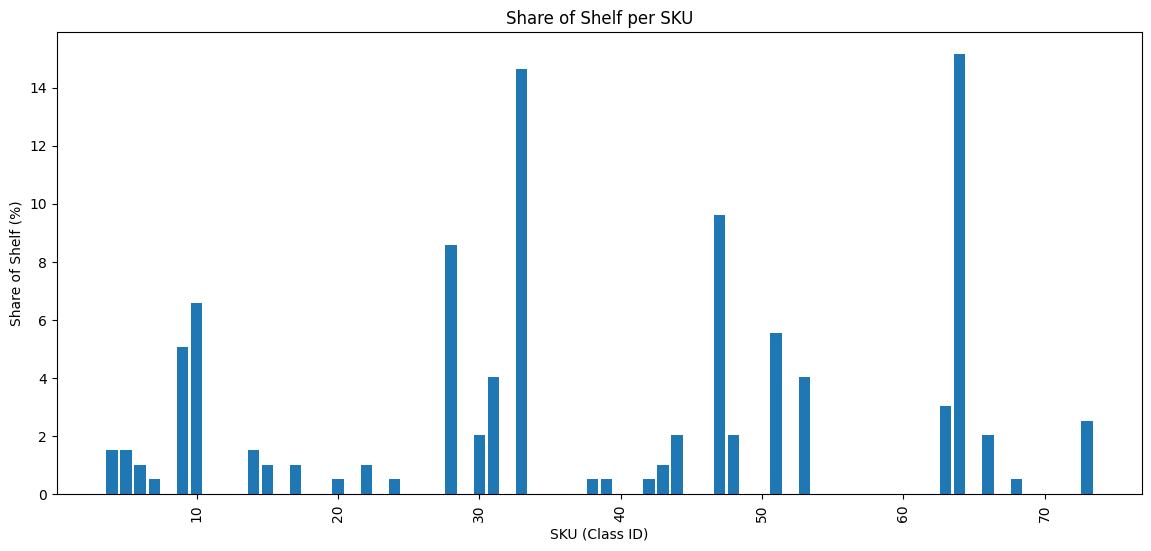

,Class_ID,Count,Share_of_Shelf (%)
10,64,30,15.151515
4,33,29,14.646465
14,47,19,9.595960
11,28,17,8.585859
24,10,13,6.565657
12,51,11,5.555556
0,9,10,5.050505
22,53,8,4.040404
27,31,8,4.040404
26,63,6,3.030303


In [23]:
test_path = "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images"
compute_share_of_shelf(model, test_path, conf=0.25, iou=0.5, visualize=True)

In [24]:
model.predict(
    source="/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images",
    save=True,
    save_txt=True
)

Results saved to /kaggle/working/runs/detect/predict
32 labels saved to /kaggle/working/runs/detect/predict/labels


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '0', 1: '1', 2: '10', 3: '11', 4: '12', 5: '13', 6: '14', 7: '15', 8: '16', 9: '17', 10: '18', 11: '19', 12: '2', 13: '20', 14: '21', 15: '22', 16: '23', 17: '24', 18: '25', 19: '26', 20: '27', 21: '28', 22: '29', 23: '3', 24: '30', 25: '31', 26: '32', 27: '33', 28: '34', 29: '35', 30: '36', 31: '37', 32: '38', 33: '39', 34: '4', 35: '40', 36: '41', 37: '42', 38: '43', 39: '44', 40: '45', 41: '46', 42: '47', 43: '48', 44: '49', 45: '5', 46: '50', 47: '51', 48: '52', 49: '53', 50: '54', 51: '55', 52: '56', 53: '57', 54: '58', 55: '59', 56: '6', 57: '60', 58: '61', 59: '62', 60: '63', 61: '64', 62: '65', 63: '66', 64: '67', 65: '68', 66: '69', 67: '7', 68: '70', 69: '71', 70: '72', 71: '73', 72: '74', 73: '75', 74: '8', 75: '9'}
 obb: None
 orig_img: array([[[155, 198, 207],
         [159, 202, 211],
         [143, 185, 197],
         ...

Files inside run folder:
['BoxF1_curve.png', 'val_batch0_pred.jpg', 'train_batch2.jpg', 'val_batch0_labels.jpg', 'train_batch1.jpg', 'weights', 'results.png', 'train_batch0.jpg', 'val_batch1_labels.jpg', 'BoxR_curve.png', 'BoxPR_curve.png', 'confusion_matrix_normalized.png', 'confusion_matrix.png', 'BoxP_curve.png', 'val_batch1_pred.jpg', 'results.csv', 'args.yaml', 'labels.jpg']


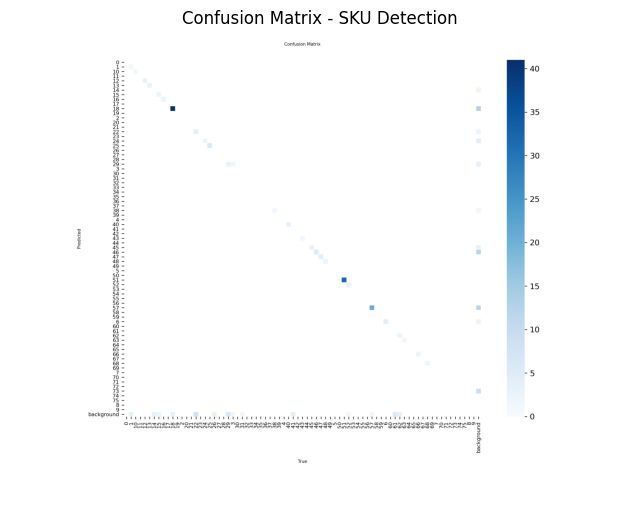

In [26]:
import os
import cv2
import matplotlib.pyplot as plt

base_path = "/kaggle/working/sku_detection/yolo11n2"

# List files inside run folder
print("Files inside run folder:")
print(os.listdir(base_path))

cm_path = os.path.join(base_path, "confusion_matrix.png")

if os.path.exists(cm_path):
    img = cv2.imread(cm_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion Matrix - SKU Detection")
    plt.show()
else:
    print("❌ confusion_matrix.png not found.")

In [27]:
from ultralytics import YOLO

# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11n2/weights/best.pt")

metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.15,      # lower threshold
    iou=0.5,
    plots=True
)

# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,610,556 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.2 ms, read: 207.8±22.2 MB/s, size: 97.5 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 802.5it/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.6it/s 1.1s1.0s
                   all         35        145      0.684      0.741      0.733      0.486
                    12          1          3          1          1      0.995       0.73
                    13          1          3          1          1      0.995      0.641
                    14          2    

**yolo11n - 960**

In [29]:
pretrained_model = YOLO("yolo11n.pt")
results = pretrained_model.train(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    epochs=100,
    imgsz=960,
    batch=16,
    device=0,
    patience=20,
    project="/kaggle/working/sku_detection",
    name="yolo11n-960"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n-960, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

In [30]:
from ultralytics import YOLO

# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11n-960/weights/best.pt")
metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.25,     
    iou=0.5,
    plots=True
)
# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,610,556 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 1.8±0.1 ms, read: 191.4±20.0 MB/s, size: 97.5 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 571.2it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5it/s 2.1s1.6s
                   all         35        145      0.767      0.742      0.779      0.526
                    12          1          3          1          1      0.995      0.724
                    13          1          3          1          1      0.995      0.631
                    14          2    

In [31]:
from ultralytics import YOLO

# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11n-960/weights/best.pt")
metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.15,     
    iou=0.5,
    plots=True
)
# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,610,556 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.0 ms, read: 231.6±26.1 MB/s, size: 97.5 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 871.6it/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5it/s 1.9s1.7s
                   all         35        145      0.746      0.778      0.801       0.54
                    12          1          3          1          1      0.995      0.724
                    13          1          3          1          1      0.995      0.631
                    14          2    

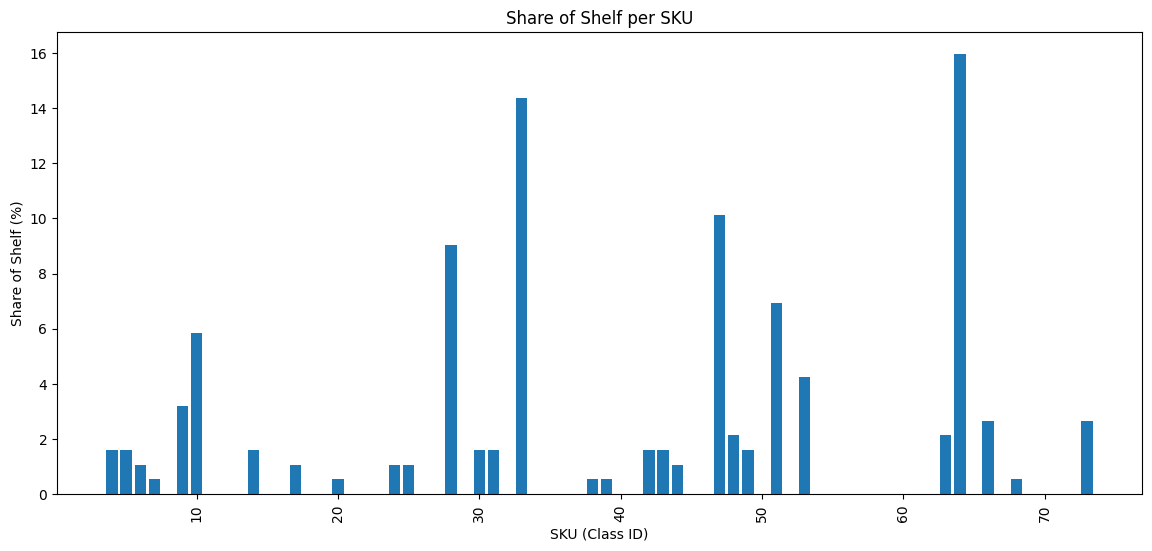

,Class_ID,Count,Share_of_Shelf (%)
11,64,30,15.957447
4,33,27,14.361702
15,47,19,10.106383
12,28,17,9.042553
13,51,13,6.914894
25,10,11,5.851064
22,53,8,4.255319
0,9,6,3.191489
26,73,5,2.659574
10,66,5,2.659574


In [32]:
test_path = "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/images"
compute_share_of_shelf(model, test_path, conf=0.25, iou=0.5, visualize=True)

# **yolo11m**

In [33]:
pretrained_model = YOLO("yolo11m.pt")
results = pretrained_model.train(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=20,
    project="/kaggle/working/sku_detection",
    name="yolo11m"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [40]:
model.predict(
    source="/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images",
    save=True,
    save_txt=True
)

Results saved to /kaggle/working/runs/detect/predict2
32 labels saved to /kaggle/working/runs/detect/predict2/labels


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '0', 1: '1', 2: '10', 3: '11', 4: '12', 5: '13', 6: '14', 7: '15', 8: '16', 9: '17', 10: '18', 11: '19', 12: '2', 13: '20', 14: '21', 15: '22', 16: '23', 17: '24', 18: '25', 19: '26', 20: '27', 21: '28', 22: '29', 23: '3', 24: '30', 25: '31', 26: '32', 27: '33', 28: '34', 29: '35', 30: '36', 31: '37', 32: '38', 33: '39', 34: '4', 35: '40', 36: '41', 37: '42', 38: '43', 39: '44', 40: '45', 41: '46', 42: '47', 43: '48', 44: '49', 45: '5', 46: '50', 47: '51', 48: '52', 49: '53', 50: '54', 51: '55', 52: '56', 53: '57', 54: '58', 55: '59', 56: '6', 57: '60', 58: '61', 59: '62', 60: '63', 61: '64', 62: '65', 63: '66', 64: '67', 65: '68', 66: '69', 67: '7', 68: '70', 69: '71', 70: '72', 71: '73', 72: '74', 73: '75', 74: '8', 75: '9'}
 obb: None
 orig_img: array([[[155, 198, 207],
         [159, 202, 211],
         [143, 185, 197],
         ...

In [34]:
from ultralytics import YOLO

# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11m/weights/best.pt")
metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.25,     
    iou=0.5,
    plots=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,088,628 parameters, 0 gradients, 68.0 GFLOPs
val: Fast image access ✅ (ping: 1.8±0.2 ms, read: 184.4±34.0 MB/s, size: 97.5 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 513.4it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.6it/s 1.8s1.5s
                   all         35        145      0.669      0.666      0.697      0.465
                    12          1          3          1          1      0.995      0.697
                    13          1          3          1          1      0.995      0.531
                    14          2  

In [35]:
# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

📊 Model Evaluation Metrics
Accuracy (mAP50): 0.6970
Precision:        0.6692
Recall:           0.6657
F1 Score:         0.6674
mAP50-95:         0.4653


In [36]:
from ultralytics import YOLO

# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11m/weights/best.pt")

metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.15,     
    iou=0.5,
    plots=True
)

# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,088,628 parameters, 0 gradients, 68.0 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 142.6±45.1 MB/s, size: 97.5 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 422.1it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5it/s 1.9s1.6s
                   all         35        145      0.703      0.766      0.774      0.493
                    12          1          3       0.75          1      0.995      0.697
                    13          1          3          1          1      0.995      0.531
                    14          2  

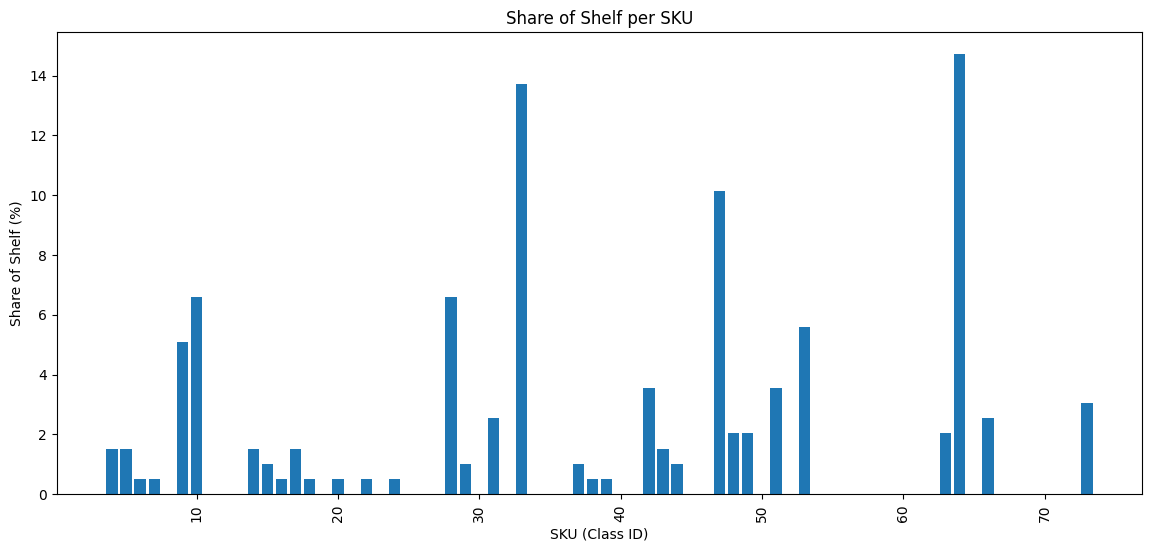

,Class_ID,Count,Share_of_Shelf (%)
11,64,29,14.720812
5,33,27,13.705584
15,47,20,10.152284
26,10,13,6.598985
12,28,13,6.598985
22,53,11,5.583756
0,9,10,5.076142
13,51,7,3.553299
21,42,7,3.553299
27,73,6,3.045685


In [38]:
test_path = "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images"
compute_share_of_shelf(model, test_path, conf=0.25, iou=0.5, visualize=True)

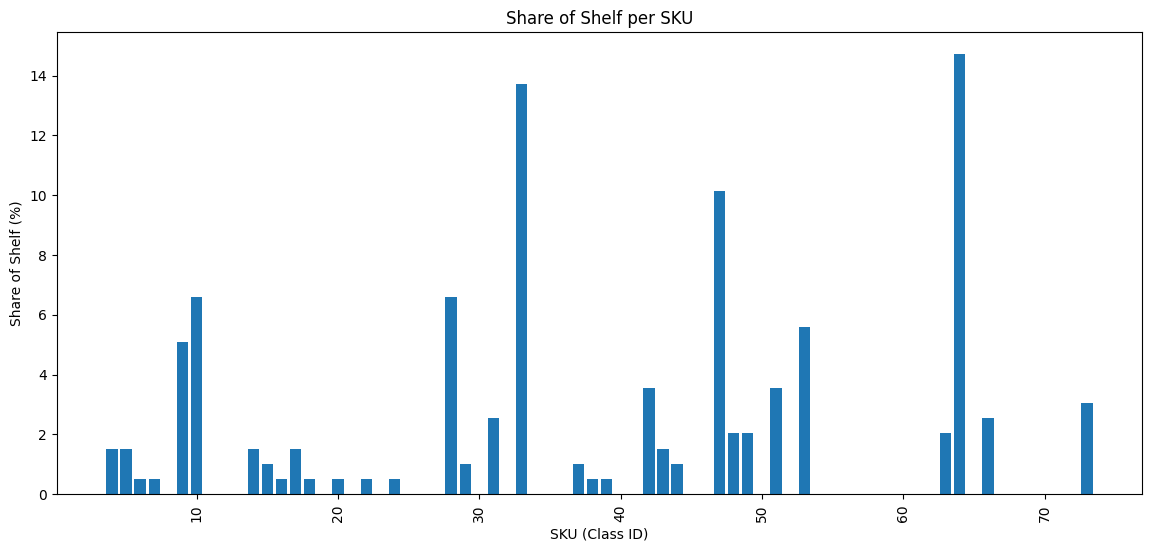

,Class_ID,Count,Share_of_Shelf (%)
11,64,29,14.720812
5,33,27,13.705584
15,47,20,10.152284
26,10,13,6.598985
12,28,13,6.598985
22,53,11,5.583756
0,9,10,5.076142
13,51,7,3.553299
21,42,7,3.553299
27,73,6,3.045685


In [39]:
test_path = "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images"
compute_share_of_shelf(model, test_path, conf=0.25, iou=0.5, visualize=True)

In [41]:
pretrained_model = YOLO("yolo11m.pt")
results = pretrained_model.train(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    epochs=100,
    imgsz=960,
    batch=16,
    device=0,
    patience=20,
    project="/kaggle/working/sku_detection",
    name="yolo11m-960"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m-960, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

In [42]:
from ultralytics import YOLO

# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11m-960/weights/best.pt")
metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.25,     
    iou=0.5,
    plots=True
)
# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,088,628 parameters, 0 gradients, 68.0 GFLOPs
val: Fast image access ✅ (ping: 1.9±0.2 ms, read: 202.6±18.8 MB/s, size: 97.8 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 544.8it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4s/it 4.1s3.3ss
                   all         35        145      0.784      0.846       0.82      0.536
                    12          1          3          1          1      0.995      0.642
                    13          1          3          1          1      0.995      0.609
                    14          2 

In [43]:
from ultralytics import YOLO

# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11m-960/weights/best.pt")
metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.15,     
    iou=0.5,
    plots=True
)
# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,088,628 parameters, 0 gradients, 68.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 162.1±62.6 MB/s, size: 99.3 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 1.1Kit/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3s/it 4.0s3.4ss
                   all         35        145      0.783      0.857       0.84       0.55
                    12          1          3          1          1      0.995      0.642
                    13          1          3          1          1      0.995      0.609
                    14          2  

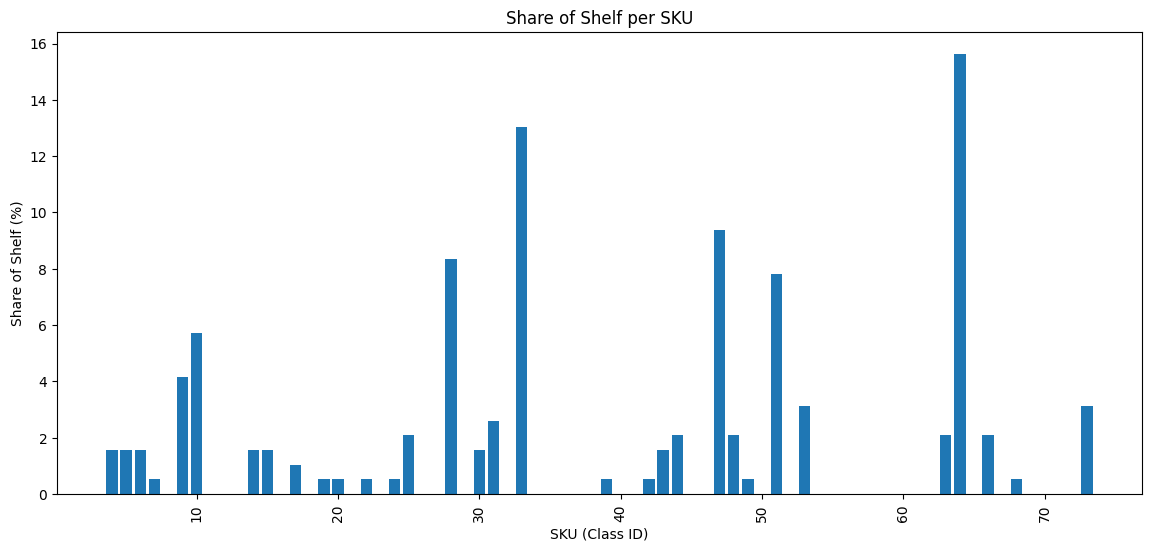

,Class_ID,Count,Share_of_Shelf (%)
11,64,30,15.625000
5,33,25,13.020833
15,47,18,9.375000
12,28,16,8.333333
13,51,15,7.812500
26,10,11,5.729167
1,9,8,4.166667
23,53,6,3.125000
27,73,6,3.125000
29,31,5,2.604167


In [44]:
test_path = "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images"
compute_share_of_shelf(model, test_path, conf=0.25, iou=0.5, visualize=True)

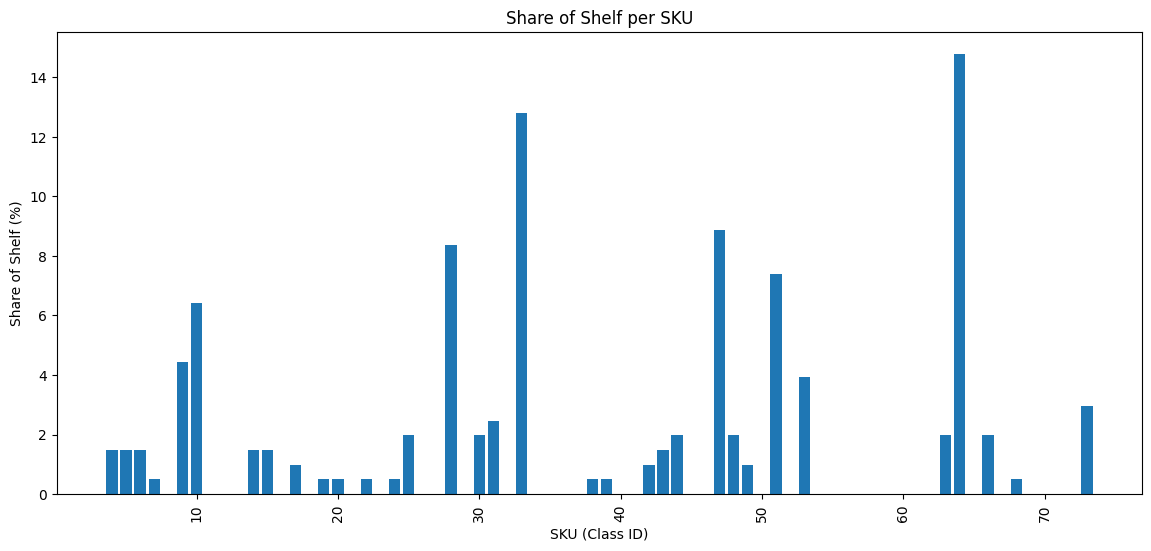

,Class_ID,Count,Share_of_Shelf (%)
12,64,30,14.778325
5,33,26,12.807882
16,47,18,8.866995
13,28,17,8.374384
14,51,15,7.389163
27,10,13,6.403941
1,9,9,4.433498
24,53,8,3.940887
28,73,6,2.955665
30,31,5,2.463054


In [45]:
test_path = "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images"
compute_share_of_shelf(model, test_path, conf=0.15, iou=0.5, visualize=True)

# **yolo11l.pt**


In [46]:
pretrained_model = YOLO("yolo11l.pt")
results = pretrained_model.train(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    epochs=100,
    imgsz=640,
    # imgsz=960,
    batch=16,
    device=0,
    patience=20,
    project="/kaggle/working/sku_detection",
    name="yolo11l"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11l, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [47]:
from ultralytics import YOLO

# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11l/weights/best.pt")

metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.25,      
    iou=0.5,
    plots=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11l summary (fused): 191 layers, 25,337,908 parameters, 0 gradients, 86.9 GFLOPs
val: Fast image access ✅ (ping: 1.8±0.3 ms, read: 207.5±30.5 MB/s, size: 97.5 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 547.5it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3it/s 2.3s1.8s
                   all         35        145      0.698      0.697      0.728      0.474
                    12          1          3          1          1      0.995      0.686
                    13          1          3          1          1      0.995      0.554
                    14          2  

In [48]:
# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

📊 Model Evaluation Metrics
Accuracy (mAP50): 0.7284
Precision:        0.6981
Recall:           0.6971
F1 Score:         0.6976
mAP50-95:         0.4738


In [50]:
model.predict(
    source="/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images",
    save=True,
    save_txt=True
)


image 1/35 /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images/db1050_jpg.rf.6c337978ee69a3a3a31ce3063e861053.jpg: 640x640 (no detections), 47.6ms
image 2/35 /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images/db1127_jpg.rf.61a0266165bd6c8bec8f851b88a941c7.jpg: 640x640 3 17s, 47.7ms
image 3/35 /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images/db1170_jpg.rf.c7c3dd2d1600ab4f4ae08b22acf44b7f.jpg: 640x640 3 12s, 47.6ms
image 4/35 /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images/db1205_jpg.rf.c02173b52c990ff307ad8896a541f7b6.jpg: 640x640 3 13s, 38.3ms
image 5/35 /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images/db1210_jpg.rf.78c93d96b882930f89575010a4b3be97.jpg: 640x640 2 52s, 30.4ms
image 6/35 /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images/db1212_jpg.rf.6c1c5f6b8918d257a07545f7ec4c0840.jpg: 640x640 2 52s, 28.9ms
image 7/35 /kaggle/inpu

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '0', 1: '1', 2: '10', 3: '11', 4: '12', 5: '13', 6: '14', 7: '15', 8: '16', 9: '17', 10: '18', 11: '19', 12: '2', 13: '20', 14: '21', 15: '22', 16: '23', 17: '24', 18: '25', 19: '26', 20: '27', 21: '28', 22: '29', 23: '3', 24: '30', 25: '31', 26: '32', 27: '33', 28: '34', 29: '35', 30: '36', 31: '37', 32: '38', 33: '39', 34: '4', 35: '40', 36: '41', 37: '42', 38: '43', 39: '44', 40: '45', 41: '46', 42: '47', 43: '48', 44: '49', 45: '5', 46: '50', 47: '51', 48: '52', 49: '53', 50: '54', 51: '55', 52: '56', 53: '57', 54: '58', 55: '59', 56: '6', 57: '60', 58: '61', 59: '62', 60: '63', 61: '64', 62: '65', 63: '66', 64: '67', 65: '68', 66: '69', 67: '7', 68: '70', 69: '71', 70: '72', 71: '73', 72: '74', 73: '75', 74: '8', 75: '9'}
 obb: None
 orig_img: array([[[155, 198, 207],
         [159, 202, 211],
         [143, 185, 197],
         ...

In [49]:
from ultralytics import YOLO

# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11l/weights/best.pt")

metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.15, 
    iou=0.5,
    plots=True
)

# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11l summary (fused): 191 layers, 25,337,908 parameters, 0 gradients, 86.9 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.2 ms, read: 143.5±22.9 MB/s, size: 97.5 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 517.7it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4it/s 2.2s1.9s
                   all         35        145      0.687      0.734      0.742       0.48
                    12          1          3          1          1      0.995      0.686
                    13          1          3          1          1      0.995      0.554
                    14          2  

**Yello11m-960**

In [51]:
pretrained_model = YOLO("yolo11l.pt")
results = pretrained_model.train(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    epochs=100,
    # imgsz=640,
    imgsz=960,
    batch=16,
    device=0,
    patience=20,
    project="/kaggle/working/sku_detection",
    name="yolo11l-960"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11l-960, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

In [52]:
# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11l-960/weights/best.pt")

metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.25, 
    iou=0.5,
    plots=True
)
# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11l summary (fused): 191 layers, 25,337,908 parameters, 0 gradients, 86.9 GFLOPs
val: Fast image access ✅ (ping: 2.1±0.2 ms, read: 190.1±11.5 MB/s, size: 97.8 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 552.1it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5s/it 4.5s3.9ss
                   all         35        145      0.738      0.813      0.822      0.545
                    12          1          3        0.6          1      0.995      0.777
                    13          1          3          1          1      0.995      0.598
                    14          2 

In [53]:
# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11l-960/weights/best.pt")

metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.15, 
    iou=0.5,
    plots=True
)
# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11l summary (fused): 191 layers, 25,337,908 parameters, 0 gradients, 86.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 125.0±41.8 MB/s, size: 99.3 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 1.1Kit/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5s/it 4.5s3.9ss
                   all         35        145      0.716      0.816      0.824      0.546
                    12          1          3        0.6          1      0.995      0.777
                    13          1          3          1          1      0.995      0.598
                    14          2  

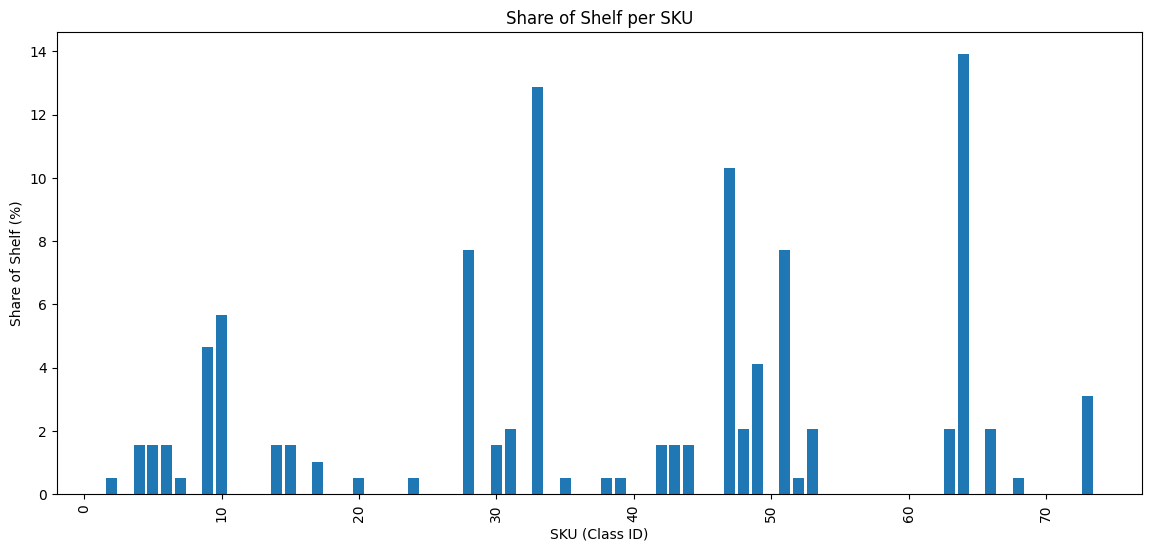

,Class_ID,Count,Share_of_Shelf (%)
10,64,27,13.917526
4,33,25,12.886598
15,47,20,10.309278
12,28,15,7.731959
13,51,15,7.731959
28,10,11,5.670103
0,9,9,4.639175
27,49,8,4.123711
29,73,6,3.092784
23,53,4,2.061856


In [54]:
test_path = "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images"
compute_share_of_shelf(model, test_path, conf=0.25, iou=0.5, visualize=True)

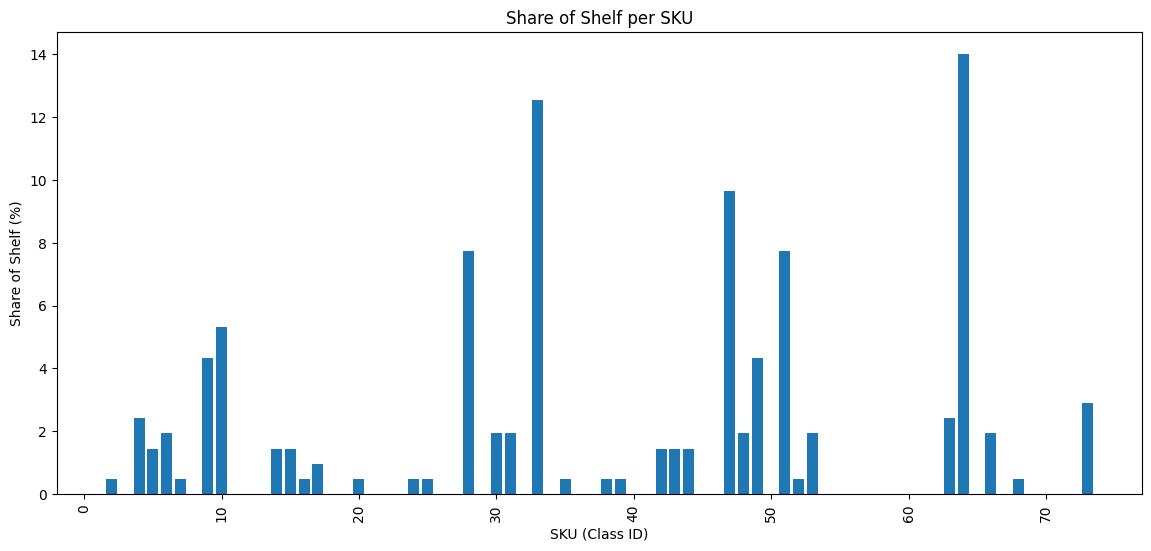

,Class_ID,Count,Share_of_Shelf (%)
12,64,29,14.009662
4,33,26,12.560386
17,47,20,9.661836
14,28,16,7.729469
15,51,16,7.729469
30,10,11,5.314010
0,9,9,4.347826
29,49,9,4.347826
31,73,6,2.898551
32,63,5,2.415459


In [56]:
test_path = "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images"
compute_share_of_shelf(model, test_path, conf=0.15, iou=0.5, visualize=True)

# **yolo11x**

In [63]:
pretrained_model = YOLO("yolo11x.pt")
results = pretrained_model.train(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    epochs=100,
    imgsz=640,
    # imgsz=960,
    batch=16,
    device=0,
    patience=20,
    project="/kaggle/working/sku_detection",
    name="yolo11x"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11x, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [64]:
# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11x/weights/best.pt")

metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.25,      # lower threshold
    iou=0.5,
    plots=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11x summary (fused): 191 layers, 56,914,804 parameters, 0 gradients, 194.9 GFLOPs
val: Fast image access ✅ (ping: 1.9±0.3 ms, read: 192.0±24.1 MB/s, size: 97.8 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 576.3it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3s/it 3.8s3.3ss
                   all         35        145      0.825      0.805      0.826      0.504
                    12          1          3          1          1      0.995      0.553
                    13          1          3          1          1      0.995      0.509
                    14          2

In [69]:
model.predict(
    source="/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images",
    save=True,
    save_txt=True
)

Results saved to /kaggle/working/runs/detect/predict4
35 labels saved to /kaggle/working/runs/detect/predict4/labels


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '0', 1: '1', 2: '10', 3: '11', 4: '12', 5: '13', 6: '14', 7: '15', 8: '16', 9: '17', 10: '18', 11: '19', 12: '2', 13: '20', 14: '21', 15: '22', 16: '23', 17: '24', 18: '25', 19: '26', 20: '27', 21: '28', 22: '29', 23: '3', 24: '30', 25: '31', 26: '32', 27: '33', 28: '34', 29: '35', 30: '36', 31: '37', 32: '38', 33: '39', 34: '4', 35: '40', 36: '41', 37: '42', 38: '43', 39: '44', 40: '45', 41: '46', 42: '47', 43: '48', 44: '49', 45: '5', 46: '50', 47: '51', 48: '52', 49: '53', 50: '54', 51: '55', 52: '56', 53: '57', 54: '58', 55: '59', 56: '6', 57: '60', 58: '61', 59: '62', 60: '63', 61: '64', 62: '65', 63: '66', 64: '67', 65: '68', 66: '69', 67: '7', 68: '70', 69: '71', 70: '72', 71: '73', 72: '74', 73: '75', 74: '8', 75: '9'}
 obb: None
 orig_img: array([[[155, 198, 207],
         [159, 202, 211],
         [143, 185, 197],
         ...

In [65]:
# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

📊 Model Evaluation Metrics
Accuracy (mAP50): 0.8262
Precision:        0.8248
Recall:           0.8050
F1 Score:         0.8148
mAP50-95:         0.5035


In [66]:
# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11x/weights/best.pt")

metrics = model.val(
    data="/kaggle/input/datasets/mirzaraquib/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.15,      # lower threshold
    iou=0.5,
    plots=True
)

# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11x summary (fused): 191 layers, 56,914,804 parameters, 0 gradients, 194.9 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 245.7±45.0 MB/s, size: 99.3 KB)
val: Scanning /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 920.7it/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2s/it 3.7s3.2ss
                   all         35        145      0.766      0.867       0.88       0.52
                    12          1          3          1          1      0.995      0.553
                    13          1          3       0.75          1      0.995      0.503
                    14          2

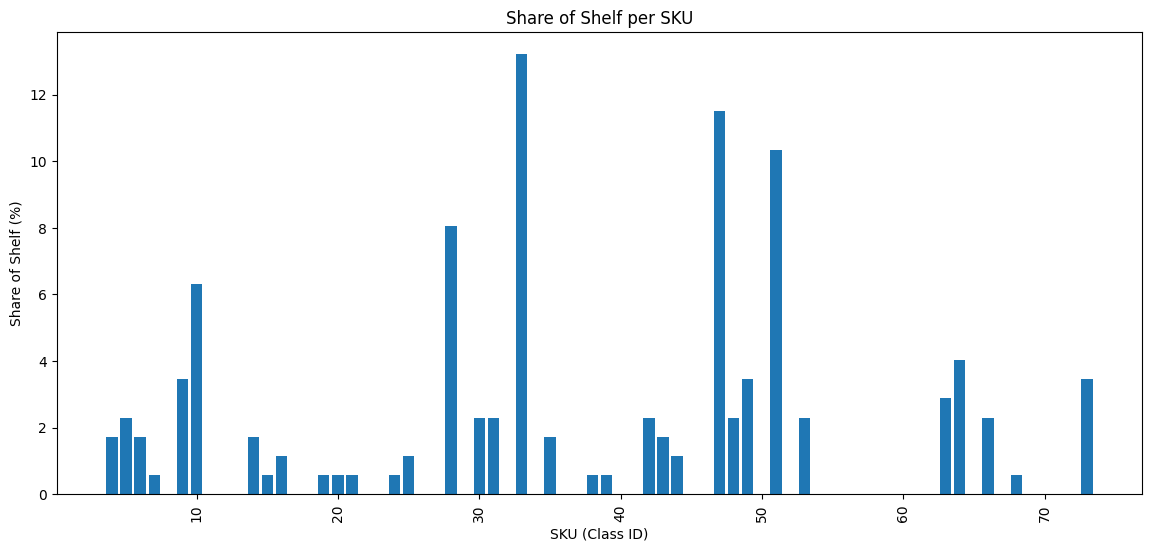

,Class_ID,Count,Share_of_Shelf (%)
5,33,23,13.218391
20,47,20,11.494253
18,51,18,10.344828
16,28,14,8.045977
30,10,11,6.321839
15,64,7,4.022989
29,49,6,3.448276
1,9,6,3.448276
31,73,6,3.448276
17,63,5,2.873563


In [67]:
test_path = "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images"
compute_share_of_shelf(model, test_path, conf=0.25, iou=0.5, visualize=True)

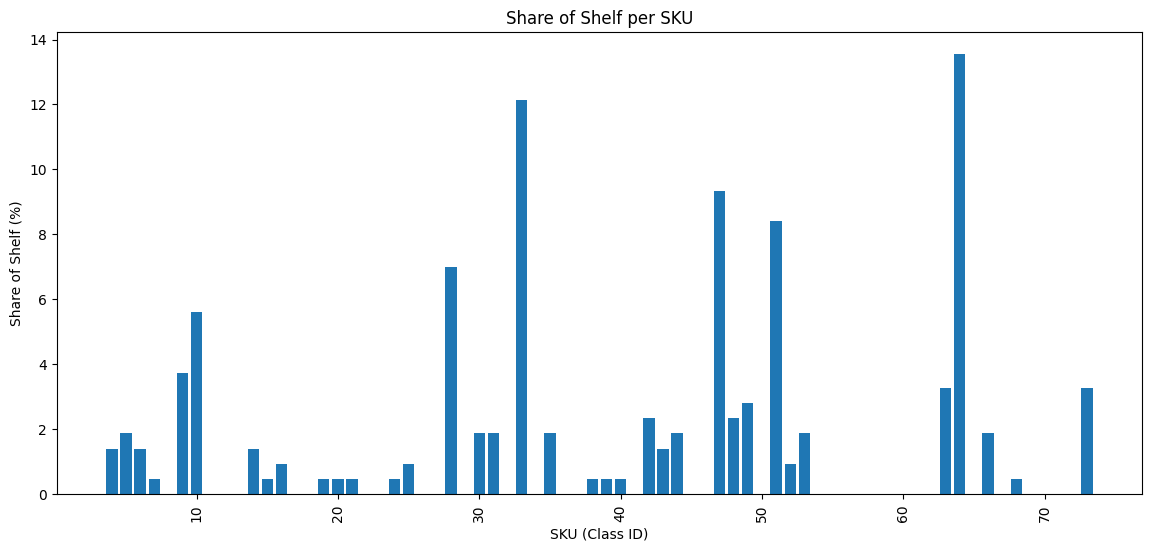

,Class_ID,Count,Share_of_Shelf (%)
16,64,29,13.551402
5,33,26,12.149533
22,47,20,9.345794
20,51,18,8.411215
18,28,15,7.009346
33,10,12,5.607477
1,9,8,3.738318
19,73,7,3.271028
12,63,7,3.271028
32,49,6,2.803738


In [68]:
test_path = "/kaggle/input/datasets/mirzaraquib/im-intern-resouces/MI-Intern/test/images"
compute_share_of_shelf(model, test_path, conf=0.15, iou=0.5, visualize=True)

**yolo11x-960**

In [2]:
!pip install ultralytics
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.6 MB/s eta 0:00:0000:01


In [3]:
from ultralytics import YOLO
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
pretrained_model = YOLO("yolo11x.pt")
results = pretrained_model.train(
    data="/kaggle/input/datasets/munazermontasirakash/data-yaml-kaggle/data.yaml",
    epochs=100,
    # imgsz=640,
    imgsz=960,
    batch=16,
    device=0,
    patience=20,
    project="/kaggle/working/sku_detection",
    name="yolo11x-960"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/munazermontasirakash/data-yaml-kaggle/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11x-960, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

In [5]:
# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11x-960/weights/best.pt")

metrics = model.val(
    data="/kaggle/input/datasets/munazermontasirakash/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.25,      # lower threshold
    iou=0.5,
    plots=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11x summary (fused): 191 layers, 56,914,804 parameters, 0 gradients, 194.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9.7±2.0 MB/s, size: 88.3 KB)
val: Scanning /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 287.1it/s 0.1s.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.7s/it 8.2s7.1s2s
                   all         35        145      0.739      0.831       0.82       0.53
                    12          1          3          1          1      0.995      0.719
                    13          1          3          1          1      0.995      0.609
                    14        

In [6]:
model.predict(
    source="/kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/images",
    save=True,
    save_txt=True
)


image 1/35 /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/images/db1050_jpg.rf.6c337978ee69a3a3a31ce3063e861053.jpg: 960x960 (no detections), 175.6ms
image 2/35 /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/images/db1127_jpg.rf.61a0266165bd6c8bec8f851b88a941c7.jpg: 960x960 9 17s, 1 75, 158.8ms
image 3/35 /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/images/db1170_jpg.rf.c7c3dd2d1600ab4f4ae08b22acf44b7f.jpg: 960x960 3 12s, 153.9ms
image 4/35 /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/images/db1205_jpg.rf.c02173b52c990ff307ad8896a541f7b6.jpg: 960x960 3 13s, 161.6ms
image 5/35 /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/images/db1210_jpg.rf.78c93d96b882930f89575010a4b3be97.jpg: 960x960 2 52s, 162.6ms
image 6/35 /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/images/db1212_jpg.rf.6c1c5f6b8918d257a0

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '0', 1: '1', 2: '10', 3: '11', 4: '12', 5: '13', 6: '14', 7: '15', 8: '16', 9: '17', 10: '18', 11: '19', 12: '2', 13: '20', 14: '21', 15: '22', 16: '23', 17: '24', 18: '25', 19: '26', 20: '27', 21: '28', 22: '29', 23: '3', 24: '30', 25: '31', 26: '32', 27: '33', 28: '34', 29: '35', 30: '36', 31: '37', 32: '38', 33: '39', 34: '4', 35: '40', 36: '41', 37: '42', 38: '43', 39: '44', 40: '45', 41: '46', 42: '47', 43: '48', 44: '49', 45: '5', 46: '50', 47: '51', 48: '52', 49: '53', 50: '54', 51: '55', 52: '56', 53: '57', 54: '58', 55: '59', 56: '6', 57: '60', 58: '61', 59: '62', 60: '63', 61: '64', 62: '65', 63: '66', 64: '67', 65: '68', 66: '69', 67: '7', 68: '70', 69: '71', 70: '72', 71: '73', 72: '74', 73: '75', 74: '8', 75: '9'}
 obb: None
 orig_img: array([[[155, 198, 207],
         [159, 202, 211],
         [143, 185, 197],
         ...

In [7]:
# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

📊 Model Evaluation Metrics
Accuracy (mAP50): 0.8202
Precision:        0.7393
Recall:           0.8313
F1 Score:         0.7826
mAP50-95:         0.5298


In [8]:
# Load trained best model
model = YOLO("/kaggle/working/sku_detection/yolo11x-960/weights/best.pt")

metrics = model.val(
    data="/kaggle/input/datasets/munazermontasirakash/data-yaml-kaggle/data.yaml",
    split="test",
    conf=0.15,      # lower threshold
    iou=0.5,
    plots=True
)

# Precision
precision = metrics.box.mp

# Recall
recall = metrics.box.mr

# mAP50
map50 = metrics.box.map50

# mAP50-95
map = metrics.box.map

# F1 Score (calculated manually)
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

# Accuracy approximation (for detection, mAP50 is commonly used)
accuracy = map50

print("📊 Model Evaluation Metrics")
print(f"Accuracy (mAP50): {accuracy:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print(f"mAP50-95:         {map:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11x summary (fused): 191 layers, 56,914,804 parameters, 0 gradients, 194.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 119.2±22.8 MB/s, size: 91.0 KB)
val: Scanning /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 1.1Kit/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.9s/it 8.8s7.7s5s
                   all         35        145      0.743      0.866      0.851      0.537
                    12          1          3          1          1      0.995      0.719
                    13          1          3          1          1      0.995      0.609
                    14         

In [10]:
import os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

def compute_share_of_shelf(model, test_path, conf=0.20, iou=0.6, visualize=True):

    # Run prediction
    results = model.predict(
        source=test_path,
        conf=conf,
        iou=iou,
        save=False,
        verbose=False
    )

    # Count detections per class
    class_counts = Counter()

    for r in results:
        if r.boxes is not None:
            for cls in r.boxes.cls:
                class_id = int(cls.item())
                class_counts[class_id] += 1

    # Total detections
    total_detections = sum(class_counts.values())

    if total_detections == 0:
        print("No detections found.")
        return None

    # Compute Share of Shelf
    data = []
    for class_id, count in class_counts.items():
        share = (count / total_detections) * 100
        data.append([class_id, count, share])

    df = pd.DataFrame(data, columns=["Class_ID", "Count", "Share_of_Shelf (%)"])
    df = df.sort_values(by="Share_of_Shelf (%)", ascending=False)

    # Visualization
    if visualize:
        plt.figure(figsize=(14,6))
        plt.bar(df["Class_ID"], df["Share_of_Shelf (%)"])
        plt.xlabel("SKU (Class ID)")
        plt.ylabel("Share of Shelf (%)")
        plt.title("Share of Shelf per SKU")
        plt.xticks(rotation=90)
        plt.show()

    return df

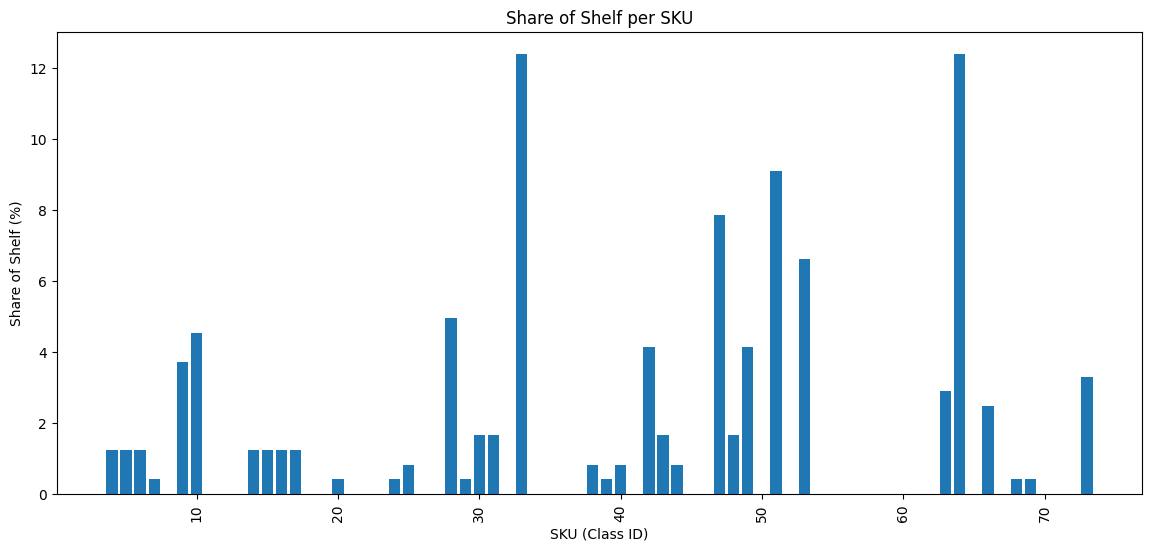

,Class_ID,Count,Share_of_Shelf (%)
5,33,30,12.396694
14,64,30,12.396694
17,51,22,9.090909
20,47,19,7.851240
28,53,16,6.611570
15,28,12,4.958678
30,10,11,4.545455
27,42,10,4.132231
18,49,10,4.132231
0,9,9,3.719008


In [11]:
test_path = "/kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/images"
compute_share_of_shelf(model, test_path, conf=0.15, iou=0.5, visualize=True)

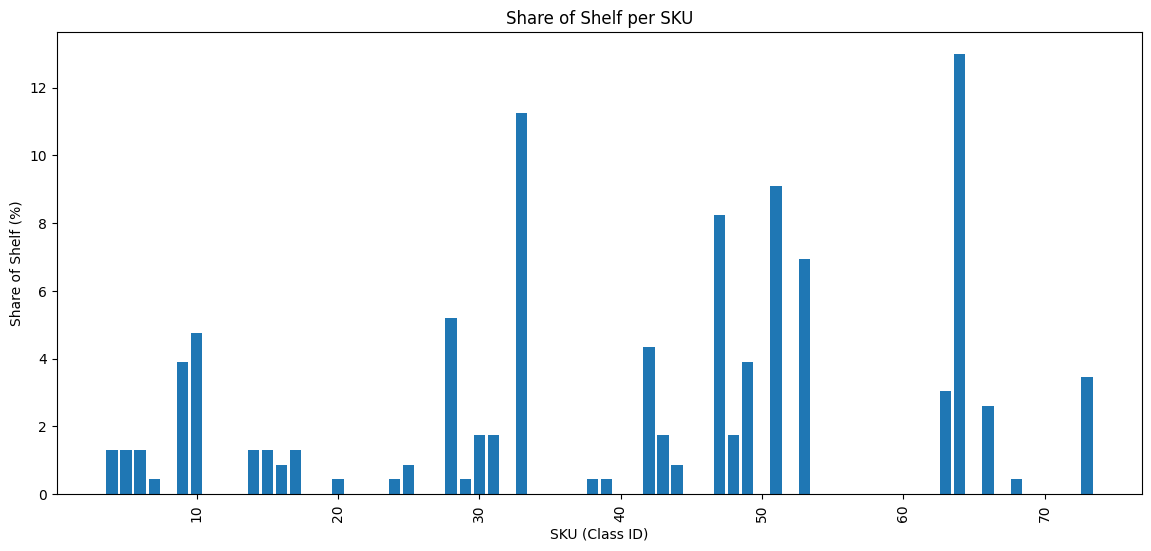

,Class_ID,Count,Share_of_Shelf (%)
14,64,30,12.987013
5,33,26,11.255411
16,51,21,9.090909
19,47,19,8.225108
26,53,16,6.926407
15,28,12,5.194805
28,10,11,4.761905
25,42,10,4.329004
0,9,9,3.896104
17,49,9,3.896104


In [12]:
test_path = "/kaggle/input/datasets/munazermontasirakash/im-intern-resouces/MI-Intern/test/images"
compute_share_of_shelf(model, test_path, conf=0.25, iou=0.5, visualize=True)